# Example 9: Bayesian optimization using database file

This notebook demonstrates how to perform Bayesian optimization (BO) for model calibration and parameter estimation using a custom PhysiCell model. Bayesian optimization is a powerful technique for optimizing expensive black-box functions, making it ideal for calibrating computational models against experimental or observational data.

The calibration process uses a multi-objective approach to minimize the discrepancy between model predictions and observed data across multiple quantities of interest (QoIs). The method employs:

1. **Gaussian Process surrogate models**: To efficiently approximate the parameter-to-QoI mapping
2. **Acquisition functions**: To intelligently select new parameter combinations for evaluation
3. **Multi-objective optimization**: To simultaneously optimize multiple fitness criteria
4. **Pareto front analysis**: To identify trade-offs between competing objectives

The observational data represents the "ground truth" generated from a single simulation with known parameter values:
- **cell_cycle_entry**: 1440.0 (mean duration of cell in quiescent mode).
- **apoptosis_rate**: 5.787e-05 (rate of cell to become apoptotic).

The *in silico* observational data ([ObsData.csv](ObsData.csv)) was generated using [GenerateData.ipynb](GenerateData.ipynb). The goal is to recover these parameter values through the optimization process.

## Import modules and set up parameters

In [1]:
from uq_physicell.bo import CalibrationContext, run_bayesian_optimization, analyze_pareto_results, plot_parameter_space, plot_qoi_param, plot_parameter_vs_fitness, get_observed_qoi
from uq_physicell.database.bo_db import load_structure

import matplotlib.pyplot as plt
# Real values for obs. data
dic_real_value = {'cell_cycle_entry': 1440.0, 'apoptosis_rate': 5.787e-05}
# File name
db_path = "Calib_BO.db"
obs_data_path = "ObsData.csv"
# Model configuration
model_config = {
    "ini_path": "uq_config.ini", 
    "struc_name": "ModelA", 
}
# Quantities of Interest (QoI) functions
qoi_functions = {
    'live_cell_count': "lambda df: len( df[ df['dead'] == False ])",
    'sum_dead_cell_count': "lambda mcds_ts: sum(map(lambda mcds: len(mcds.get_cell_df()[mcds.get_cell_df()['dead'] == True]), mcds_ts))"     
}
# Mapping of QoI names to observed data columns
obs_data_columns = {
    'time': "Time", 
    "live_cell_count": "Live_Cells", 
    "sum_dead_cell_count": "Sum_Dead_Cells"
}

# Bayesian Optimization options
bo_options = {
    "db_path_initial_samples": "Simulations.db",  # Database with initial samples
    "num_iterations": 30,  # More iterations for better exploration
    "batch_size_per_iteration": 1,  # Single candidate per iteration
    "max_workers": 5,  # Reduced for stability
}

In [2]:
# Create the calibration context
calib_context = CalibrationContext(
    db_path=db_path,
    obsData=obs_data_path,
    obsData_columns=obs_data_columns,
    model_config=model_config,
    qoi_functions=qoi_functions,
    bo_options=bo_options,
)
# Run the Bayesian Optimization calibration
run_bayesian_optimization(calib_context)

2026-01-23 10:33:09,288 - INFO - 🧪 Initial samples will be generated from existing database at Simulations.db.
2026-01-23 10:33:09,290 - INFO - 📊 Estimating weights from observational data ranges:
  📈 live_cell_count - weight: 2.13e-05 (range=1.52e+03)
  📈 sum_dead_cell_count - weight: 9.58e-04 (range=1.04e+03)

2026-01-23 10:33:09,291 - INFO - 🔧 CalibrationContext initialized with 5 max workers, 5 inner workers, and 1 outer workers.
2026-01-23 10:33:09,291 - INFO - 🆕 Starting fresh optimization with database: Calib_BO.db
2026-01-23 10:33:09,294 - INFO - 🧪 Generating initial samples from Simulations.db...
2026-01-23 10:33:47,443 - INFO - 🔬 Detected multiple QoIs - using multi-objective Bayesian optimization loop.
2026-01-23 10:33:47,445 - INFO - ============================================================
2026-01-23 10:33:47,446 - INFO - 🔄 Multi-Objective BO Iteration 1/30
2026-01-23 10:33:47,446 - INFO - ============================================================
2026-01-23 10:33:47,

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


2026-01-23 10:33:48,931 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-01-23 10:33:48,931 - INFO - 	 Candidate 1: {'cell_cycle_entry': 1603.602283694463, 'apoptosis_rate': 6.380004e-05}
2026-01-23 10:37:59,859 - INFO - 	 Results for Sample ID 48: Objectives = {'live_cell_count': np.float64(0.09565603136172476), 'sum_dead_cell_count': np.float64(0.17248324760752176)}, Noise Std = {'live_cell_count': np.float64(0.04778658409371317), 'sum_dead_cell_count': np.float64(0.11504953933733367)}
2026-01-23 10:37:59,866 - INFO - 📊 Iteration 1 Sample(s) [48] : Hypervolume = 0.00028663075785369306
2026-01-23 10:37:59,866 - INFO - ✅ Completed iteration 1/30 - Total samples: 49
2026-01-23 10:37:59,866 - INFO - 🎯 Best fitness values:
2026-01-23 10:37:59,867 - INFO - 	 Best parameters for best fitness of live_cell_count (sample 39): {'cell_cycle_entry': 1526.73287646256, 'apoptosis_rate': 5.6972530886514257e-05}
2026-01-23 10:37:59,867 - INFO - 	 Fitness: {'live_cell_count': 0.8045753209307664, 'sum_

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/botorch/optim/optimize.py:652: RuntimeWarning: Optimization failed in `gen_candidates_scipy` with the following warning(s):
[OptimizationWarning('Optimization failed within `scipy.optimize.minimize` with status 2 and message ABNORMAL: .')]
Trying again with a new set of initial conditions.
  return _optimize_acqf_batch(opt_inputs=opt_inputs)


2026-01-23 10:38:01,872 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-01-23 10:38:01,873 - INFO - 	 Candidate 1: {'cell_cycle_entry': 1527.1875183509114, 'apoptosis_rate': 4.2533360000000006e-05}
2026-01-23 10:42:26,900 - INFO - 	 Results for Sample ID 49: Objectives = {'live_cell_count': np.float64(0.42922761734405845), 'sum_dead_cell_count': np.float64(1.0767434854920378e-17)}, Noise Std = {'live_cell_count': np.float64(0.11503147780043149), 'sum_dead_cell_count': np.float64(8.791573744404202e-18)}
2026-01-23 10:42:26,906 - INFO - 📊 Iteration 2 Sample(s) [49] : Hypervolume = 0.00030567307827148425
2026-01-23 10:42:26,906 - INFO - ✅ Completed iteration 2/30 - Total samples: 50
2026-01-23 10:42:26,907 - INFO - 🎯 Best fitness values:
2026-01-23 10:42:26,907 - INFO - 	 Best parameters for best fitness of live_cell_count (sample 39): {'cell_cycle_entry': 1526.73287646256, 'apoptosis_rate': 5.6972530886514257e-05}
2026-01-23 10:42:26,907 - INFO - 	 Fitness: {'live_cell_count': 0.8045753

...

2026-01-23 12:36:52,159 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-01-23 12:36:52,159 - INFO - 	 Candidate 1: {'cell_cycle_entry': 1608.9419570257448, 'apoptosis_rate': 4.2533360000000006e-05}
2026-01-23 12:40:57,875 - INFO - 	 Results for Sample ID 75: Objectives = {'live_cell_count': np.float64(0.3759662487879447), 'sum_dead_cell_count': np.float64(3.163286774258182e-26)}, Noise Std = {'live_cell_count': np.float64(0.13585069682271253), 'sum_dead_cell_count': np.float64(3.8742192535099356e-26)}
2026-01-23 12:40:57,880 - INFO - 📊 Iteration 28 Sample(s) [75] : Hypervolume = 0.000388297700028246
2026-01-23 12:40:57,881 - INFO - 🔍 Analyzing convergence...
2026-01-23 12:40:57,881 - WARNING - ⚠️  High noise detected (max 90.7%) - using relaxed convergence criteria
2026-01-23 12:40:57,882 - INFO - 	📋 Convergence Status: stuck_suboptimal
2026-01-23 12:40:57,882 - INFO - 	💡 Reason: Stuck in suboptimal region: poor exploration or quality despite stagnation
2026-01-23 12:40:57,882 - INFO 

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


2026-01-23 12:40:59,558 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-01-23 12:40:59,558 - INFO - 	 Candidate 1: {'cell_cycle_entry': 1560.7994933219165, 'apoptosis_rate': 4.2533360000000006e-05}
2026-01-23 12:45:08,352 - INFO - 	 Results for Sample ID 76: Objectives = {'live_cell_count': np.float64(0.7325283829940328), 'sum_dead_cell_count': np.float64(8.232696682258146e-37)}, Noise Std = {'live_cell_count': np.float64(0.2885063498354789), 'sum_dead_cell_count': np.float64(1.6465036943779402e-36)}
2026-01-23 12:45:08,358 - INFO - 📊 Iteration 29 Sample(s) [76] : Hypervolume = 0.0003963879542438786
2026-01-23 12:45:08,358 - INFO - 🔍 Analyzing convergence...
2026-01-23 12:45:08,359 - WARNING - ⚠️  High noise detected (max 90.7%) - using relaxed convergence criteria
2026-01-23 12:45:08,360 - INFO - 	📋 Convergence Status: stuck_suboptimal
2026-01-23 12:45:08,360 - INFO - 	💡 Reason: Stuck in suboptimal region: poor exploration or quality despite stagnation
2026-01-23 12:45:08,360 - INFO 

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


2026-01-23 12:45:09,842 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-01-23 12:45:09,842 - INFO - 	 Candidate 1: {'cell_cycle_entry': 1519.492123331544, 'apoptosis_rate': 6.380004e-05}
2026-01-23 12:49:21,964 - INFO - 	 Results for Sample ID 77: Objectives = {'live_cell_count': np.float64(0.5123355315456687), 'sum_dead_cell_count': np.float64(0.00960433753072404)}, Noise Std = {'live_cell_count': np.float64(0.35227237793330834), 'sum_dead_cell_count': np.float64(0.01172693165433806)}
2026-01-23 12:49:21,970 - INFO - 📊 Iteration 30 Sample(s) [77] : Hypervolume = 0.0003894153117067585
2026-01-23 12:49:21,971 - INFO - 🔍 Analyzing convergence...
2026-01-23 12:49:21,971 - WARNING - ⚠️  High noise detected (max 90.7%) - using relaxed convergence criteria
2026-01-23 12:49:21,972 - INFO - 	📋 Convergence Status: stuck_suboptimal
2026-01-23 12:49:21,972 - INFO - 	💡 Reason: Stuck in suboptimal region: poor exploration or quality despite stagnation
2026-01-23 12:49:21,972 - INFO - 	🎯 Confidence

## Obtain the Pareto front point(s)

🔍 COMPREHENSIVE PARETO ANALYSIS

📊 Extracting all Pareto points ...
🎯 Current Pareto front size: 5

🎯 CURRENT PARETO FRONT:
   Number of Pareto optimal points: 5
   Sample IDs: [4, 13, 16, 39, 67]

   📋 Pareto Front Details:
   Point 1 (Sample 4):
      Fitness: {'live_cell_count': np.float64(0.5649144394341963), 'sum_dead_cell_count': np.float64(0.8559025559873279)}
      Parameters: {'apoptosis_rate': 5.98522630694583e-05, 'cell_cycle_entry': 1559.1182049626123}
   Point 2 (Sample 13):
      Fitness: {'live_cell_count': np.float64(0.7012471264348298), 'sum_dead_cell_count': np.float64(0.6433052738103898)}
      Parameters: {'apoptosis_rate': 5.763103537976935e-05, 'cell_cycle_entry': 1461.3241750226885}
   Point 3 (Sample 16):
      Fitness: {'live_cell_count': np.float64(0.7159452132609072), 'sum_dead_cell_count': np.float64(0.38833271268108394)}
      Parameters: {'apoptosis_rate': 5.763103537976935e-05, 'cell_cycle_entry': 1461.3241750226885}
   Point 4 (Sample 39):
      Fitness:

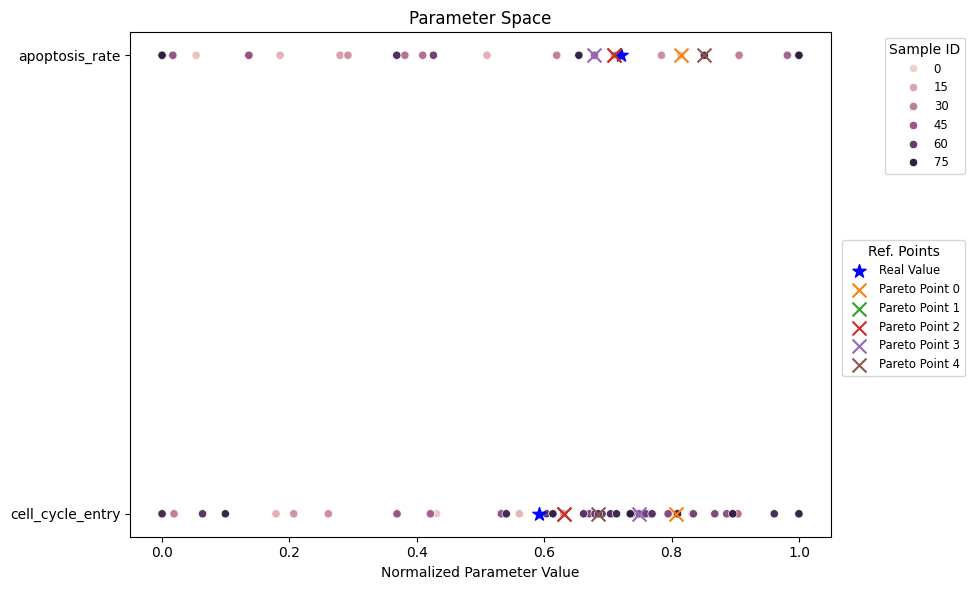

In [3]:
# Load the database and perform analysis
df_metadata, df_param_space, df_qois, df_gp_models, df_samples, df_output = load_structure(db_path)
# Comprehensive Pareto analysis
pareto_data = analyze_pareto_results(df_qois, df_samples, df_output)
# Plot with pareto front points
pareto_points = {f"Pareto Point {i}": param for i, param in enumerate(pareto_data['pareto_front']['parameters'])}
plot_parameter_space(df_samples, df_param_space, params=pareto_points, real_value=dic_real_value)
df_obs_qoi = get_observed_qoi(df_metadata['ObsData_Path'].values[0], df_qois)


## Vizualize QoIs from Pareto front point(s)

Plotting live_cell_count
Sample ID: [4, 13, 16, 39, 67]
Objective Function Values:
{'live_cell_count': np.float64(0.5649144394341963), 'sum_dead_cell_count': np.float64(0.8559025559873279)}
Noise of Objective Function:
{'live_cell_count': np.float64(0.22746576091514747), 'sum_dead_cell_count': np.float64(0.18779938784786435)}
Sample ID: [4, 13, 16, 39, 67]
Objective Function Values:
{'live_cell_count': np.float64(0.5649144394341963), 'sum_dead_cell_count': np.float64(0.8559025559873279)}
Noise of Objective Function:
{'live_cell_count': np.float64(0.22746576091514747), 'sum_dead_cell_count': np.float64(0.18779938784786435)}
Plotting sum_dead_cell_count
Sample ID: [4, 13, 16, 39, 67]
Objective Function Values:
{'live_cell_count': np.float64(0.5649144394341963), 'sum_dead_cell_count': np.float64(0.8559025559873279)}
Noise of Objective Function:
{'live_cell_count': np.float64(0.22746576091514747), 'sum_dead_cell_count': np.float64(0.18779938784786435)}
Sample ID: [4, 13, 16, 39, 67]
Object

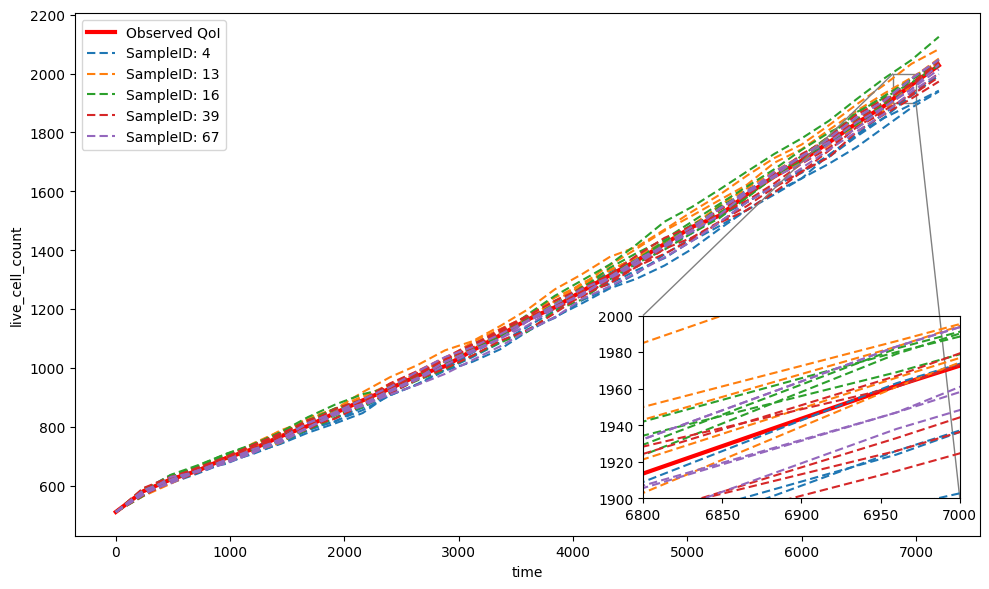

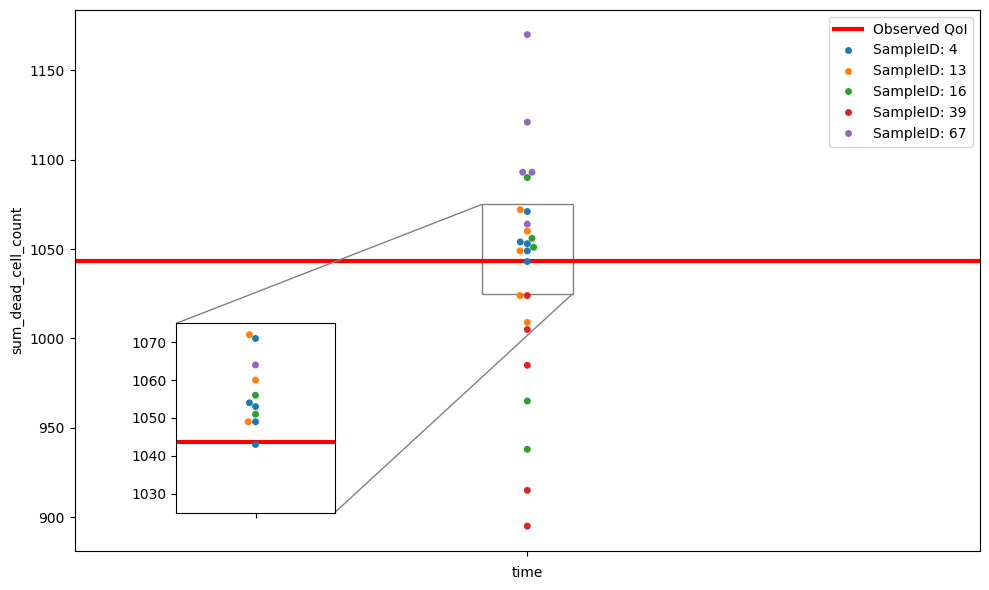

In [4]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
# Plot QoIs of best parameters
for qoi in df_qois['QoI_Name']:
    print(f"Plotting {qoi}")
    fig, ax = plot_qoi_param(df_obs_qoi, df_output, pareto_data['pareto_front']['sample_ids'], x_var='time', y_var=qoi, swarmplot=True)# 
    if qoi == 'live_cell_count':
        # Insert a zoomed-in plot
        axins = inset_axes(ax, width="35%", height="35%", loc="lower right", bbox_to_anchor=(-0.01, 0.05, 1, 1), bbox_transform=ax.transAxes, borderpad=0.8)
        plot_qoi_param(df_obs_qoi, df_output, pareto_data['pareto_front']['sample_ids'], x_var='time', y_var=qoi, axis=axins)# 
        axins.set_xlim(6800,7000)
        axins.set_ylim(1900, 2000)
        axins.set(xlabel='', ylabel='')
        axins.get_legend().set_visible(False)
    else:
        # Insert a zoomed-in plot
        axins = inset_axes(ax, width="35%", height="35%", loc="lower left", bbox_to_anchor=(0.1, 0.05, 0.5, 1), bbox_transform=ax.transAxes, borderpad=0.8)
        plot_qoi_param(df_obs_qoi, df_output, pareto_data['pareto_front']['sample_ids'], x_var='time', y_var=qoi, swarmplot=True, axis=axins)#
        axins.set_xlim(-0.05, 0.05)
        axins.set_ylim(1025, 1075)
        axins.set(xlabel='', ylabel='')
        axins.get_legend().set_visible(False)

    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
    plt.savefig(f'{qoi}_BO.svg', format='svg')


## Vizualize the QoIs fitness vs Parameters values

Plotting cell_cycle_entry vs live_cell_count
Plotting cell_cycle_entry vs sum_dead_cell_count
Plotting apoptosis_rate vs live_cell_count
Plotting apoptosis_rate vs sum_dead_cell_count


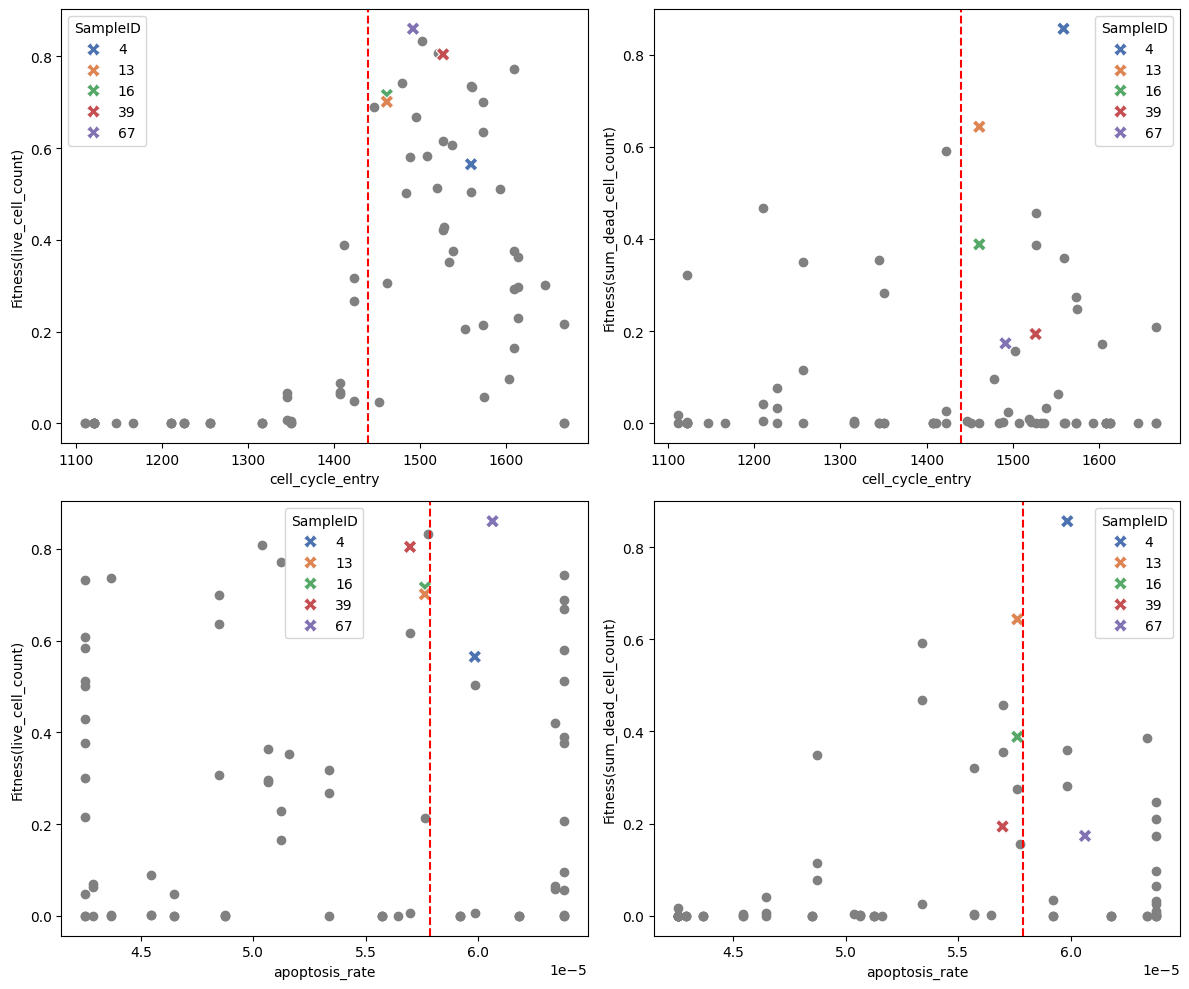

In [5]:
# Plot each parameter vs each QoI
fig, axes = plt.subplots(len(df_param_space), len(df_qois['QoI_Name']), figsize=(12, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Increased spacing
for i, param in enumerate(df_param_space['ParamName']):
    for j, qoi in enumerate(df_qois['QoI_Name']):
        print(f"Plotting {param} vs {qoi}")
        plot_parameter_vs_fitness(df_samples, df_output, param, qoi, samples_id=pareto_data['pareto_front']['sample_ids'], axis= axes[i, j])
        # Plot real value
        axes[i, j].axvline(dic_real_value[param], color='red', linestyle='--', label='Real Value')

# Ensure proper layout and save the figure
plt.tight_layout()  # This will automatically adjust spacing to prevent overlaps

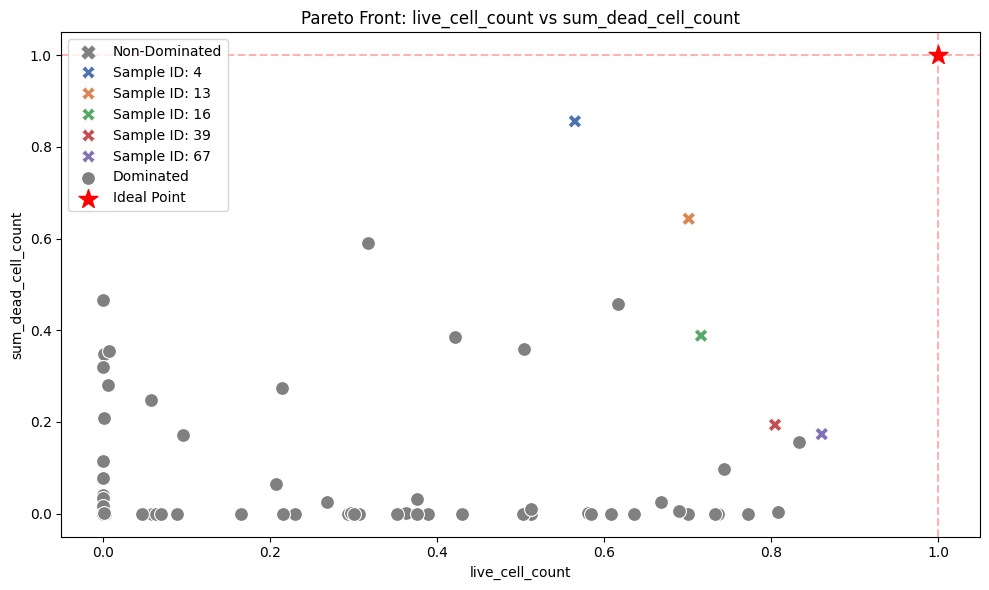

In [5]:
from uq_physicell.bo.plots import plot_pareto_front
plot_pareto_front(df_output, 'live_cell_count', 'sum_dead_cell_count', samples_id=pareto_data['pareto_front']['sample_ids'])
plt.savefig(f'Pareto_front_BO.svg', format='svg')

In [6]:
from uq_physicell.model_analysis import ModelAnalysisContext, run_simulations



db_path = "PostCalibData.db"  # Path to the database file
model_config = {"ini_path": "uq_config.ini", "struc_name": "ModelA"} # Example model configuration
sampler = 'Custom'  # Example sampler
params_info = { # Example parameters information
    'cell_cycle_entry': {'ref_value': 1440.0, 'perturbation': None},
    'apoptosis_rate': {'ref_value': 5.787e-05, 'perturbation': None}
}  

# Create Model Analysis Context
context = ModelAnalysisContext(db_path, model_config, sampler, params_info, qois_info=None, num_workers=8)
# Sample parameter sets and run simulations
pareto_points = pareto_data['pareto_front']['sample_ids']
context.dic_samples = df_samples[df_samples['SampleID'].isin(pareto_points)].pivot(index="SampleID", columns="ParamName", values="ParamValue").to_dict(orient='index')
context.dic_samples[0] = dic_real_value
run_simulations(context)


Simulations completed and results stored in the database: PostCalibData.db.


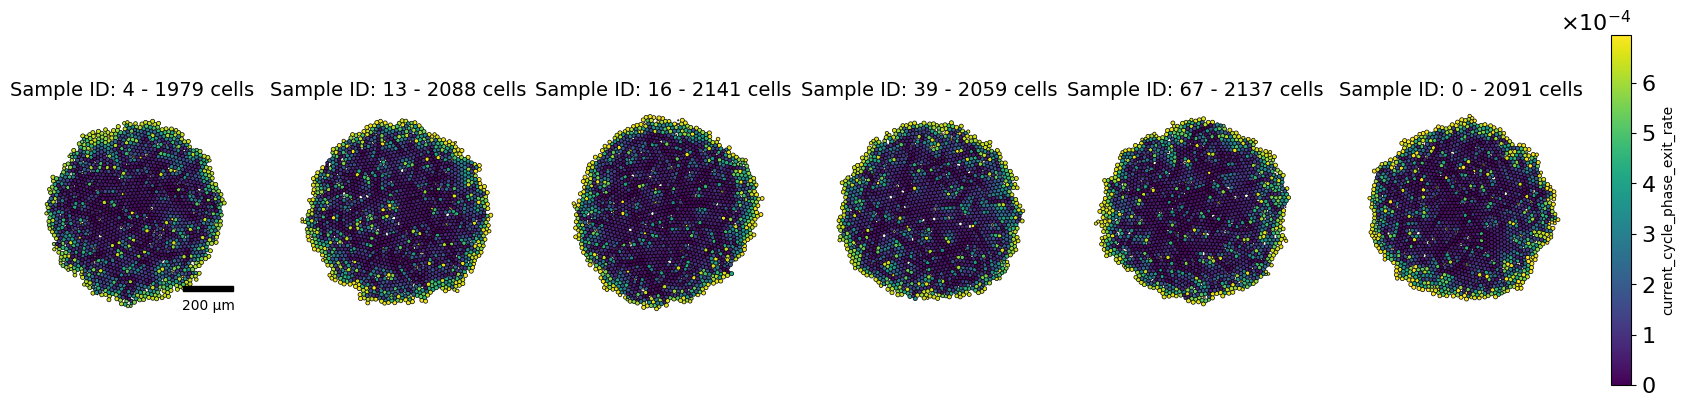

In [7]:
from uq_physicell.database.ma_db import load_output
from uq_physicell.gui.utils import plot_cells_2D
import pandas as pd
import matplotlib.ticker as ticker



replicate_id = 0  # Assuming you want to load the first replicate
feature = 'current_cycle_phase_exit_rate'  # feature to plot in cmap
min_value = 0.0; max_value = 1/pd.DataFrame(context.dic_samples).T.min()['cell_cycle_entry']
df_qois_data_selected = load_output(db_path, sample_ids=pareto_points+[0], replicate_ids=[replicate_id], load_data=True)
fig, axes = plt.subplots(1, 6, figsize=(20, 5), sharex=True, sharey=True)

for ax_id, sample_id in enumerate(pareto_points+[0]):
    mcds_last_time = df_qois_data_selected[df_qois_data_selected['SampleID'] == sample_id].iloc[0]['Data'][-1]
    df_cell = mcds_last_time.get_cell_df()
    if mcds_last_time.get_time() != 7200:
        print(f"Sample ID {sample_id} has last time {mcds_last_time.get_time()} instead of 7200")
    last_collection = plot_cells_2D(df_cell, ax=axes[ax_id], scale_bar=True if (ax_id==0) else False, feature=feature, cmap='viridis', vmin=min_value, vmax=max_value)
    axes[ax_id].set_title(f'Sample ID: {sample_id} - {len(df_cell)} cells', fontsize=14)

# cbar = fig.colorbar(last_collection, ax=axes[-1], fraction=0.05, pad=0.02)    
fig.subplots_adjust(right=0.90)
cax = fig.add_axes([0.92, 0.15, 0.01, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(last_collection, cax=cax)
# Configure the formatter to use scientific notation
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2)) # Adjusts when sci-notation kicks in
cbar.ax.tick_params(labelsize=16)               # tick labels
cbar.ax.yaxis.get_offset_text().set_size(16)    # scientific notation text (e.g., ×10⁻³)
cbar.ax.yaxis.set_major_formatter(formatter)
cbar.set_label(feature)
# plt.tight_layout()
plt.savefig(f'last_snapshots_{feature}_pareto_points.svg', format='svg')
